# Satellite Image Classification — VGG16 + Quantization (TensorFlow)

## 1. Imports

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("TF version:", tf.__version__)
print("GPU available:", len(gpus) > 0)

TF version: 2.20.0
GPU available: True


## 2. Kaggle Setup

In [2]:
from google.colab import files
files.upload()

Saving kaggle3.json to kaggle3.json


{'kaggle3.json': b'{"username":"rambhadrakumar","key":"32c81b7b282d0e78edb892f9a59b7c1b"}'}

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle datasets download -d mahmoudreda55/satellite-image-classification --unzip -p /content/satellite')
print("Download complete!")
print(sorted(os.listdir('/content/satellite/data')))

Download complete!
['cloudy', 'desert', 'green_area', 'water']


## 3. Config

In [4]:
DATA_DIR    = '/content/satellite/data'
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_P1   = 15
EPOCHS_P2   = 15
AUTOTUNE    = tf.data.AUTOTUNE

class_names_list = sorted(os.listdir(DATA_DIR))
NUM_CLASSES      = len(class_names_list)
print("Classes:", class_names_list)
print("Number of classes:", NUM_CLASSES)

Classes: ['cloudy', 'desert', 'green_area', 'water']
Number of classes: 4


## 4. Data Loaders

In [5]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches  :", len(val_ds))

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.
Classes: ['cloudy', 'desert', 'green_area', 'water']
Train batches: 141
Val batches  : 36


In [6]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

## 5. Sample Images

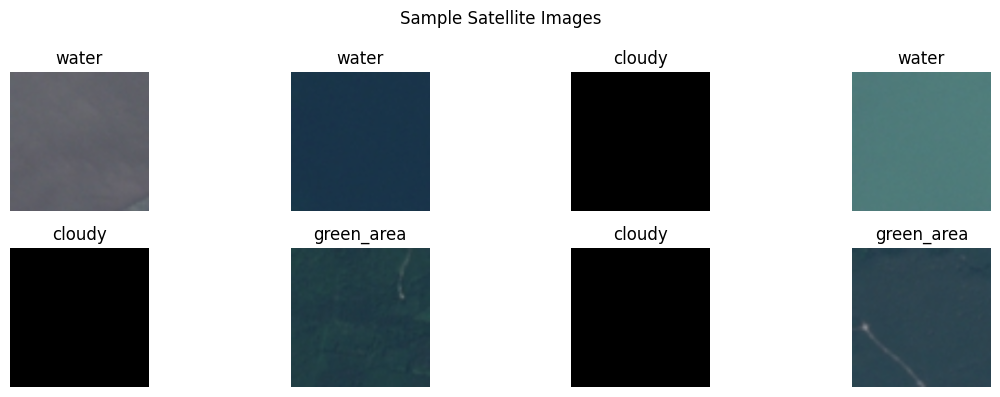

In [7]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Satellite Images')
plt.tight_layout()
plt.show()

## 6. Build VGG16 Model

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu',
                        kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu',
                        kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                        kernel_initializer='glorot_uniform')(x)

model = keras.Model(inputs, outputs)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,114,820 (57.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 14,717,248 (56.14 MB)

## 7. Phase 1 — Train Classifier Head

In [9]:
callbacks_p1 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint('best_model_p1.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 1: Training classifier head ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1
)

=== PHASE 1: Training classifier head ===
Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - accuracy: 0.9572 - loss: 0.2622 - val_accuracy: 0.2931 - val_loss: 1.4998 - learning_rate: 0.0010
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 156ms/step - accuracy: 0.9743 - loss: 0.1930 - val_accuracy: 0.5329 - val_loss: 1.2705 - learning_rate: 0.0010
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.9789 - loss: 0.1721 - val_accuracy: 0.9245 - val_loss: 0.4483 - learning_rate: 0.0010
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step - accuracy: 0.9811 - loss: 0.1531 - val_accuracy: 0.9840 - val_loss: 0.1675 - learning_rate: 0.0010
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - accuracy: 0.9858 - loss: 0.1500 - val_accuracy: 0.9805 - val_loss: 0.1565 - learning_rate: 0.0010
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - accuracy: 0.9862 - loss: 0.1390 - val_accuracy: 0.9929 - val_loss: 0.1153 - learning_rate: 0.0010
Epoch 7/15
141/141 ━━━━━━━━━

## 8. Phase 2 — Fine-tune Top Layers

In [10]:
base_model.trainable = True

for layer in base_model.layers[:-6]:
    layer.trainable = False

callbacks_p2 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8),
    keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 2: Fine-tuning top layers (last conv block) ===")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2
)

=== PHASE 2: Fine-tuning top layers (last conv block) ===
Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.9871 - loss: 0.1339 - val_accuracy: 0.9867 - val_loss: 0.1348 - learning_rate: 1.0000e-05
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.9869 - loss: 0.1363 - val_accuracy: 0.9139 - val_loss: 0.4265 - learning_rate: 1.0000e-05
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 230ms/step - accuracy: 0.9900 - loss: 0.1245 - val_accuracy: 0.9893 - val_loss: 0.1143 - learning_rate: 1.0000e-05
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 224ms/step - accuracy: 0.9929 - loss: 0.1179 - val_accuracy: 0.9014 - val_loss: 0.4330 - learning_rate: 1.0000e-05
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.9898 - loss: 0.1212 - val_accuracy: 0.9565 - val_loss: 0.2457 - learning_rate: 1.0000e-05
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.9929 - loss: 0.1169 - val_accuracy: 0.9876 - val_loss: 0.1367 - learning_rate:

## 9. Training Curves

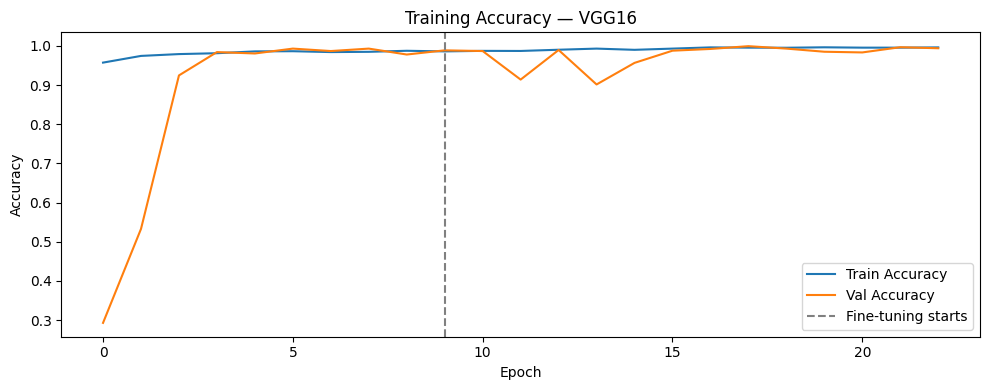

In [11]:
all_acc  = history1.history['accuracy']  + history2.history['accuracy']
all_vacc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.plot(all_acc,  label='Train Accuracy')
plt.plot(all_vacc, label='Val Accuracy')
plt.axvline(x=len(history1.history['accuracy']) - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training Accuracy — VGG16')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Load Best Model & Evaluate

In [12]:
model = keras.models.load_model('best_model.keras')

orig_loss, orig_acc = model.evaluate(val_ds)
print(f"Original Model — Loss: {orig_loss:.4f}  Accuracy: {orig_acc*100:.2f}%")

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.9991 - loss: 0.1014
Original Model — Loss: 0.1014  Accuracy: 99.91%


## 11. Save Original Model

In [13]:
model.save('satellite_vgg16.keras')
orig_size = os.path.getsize('satellite_vgg16.keras') / (1024 * 1024)
print(f"Original Model Size: {orig_size:.2f} MB")

Original Model Size: 132.84 MB


## 12. Post-Training Quantization (TFLite INT8)

In [15]:
def representative_dataset():
    count = 0
    for images, _ in train_ds:
        for img in images:
            yield [tf.expand_dims(tf.cast(img, tf.float32), 0)]
            count += 1
            if count >= 100:
                return

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS
]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open('satellite_vgg16_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

quant_size = os.path.getsize('satellite_vgg16_quantized.tflite') / (1024 * 1024)
print(f"Quantized Model Size: {quant_size:.2f} MB")
print(f"Size Reduction      : {((orig_size - quant_size) / orig_size) * 100:.1f}%")

Saved artifact at '/tmp/tmpzyjosel3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139268401355024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401357904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401358864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401358096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401359056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401357328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401359440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401359248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401359824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139268401359632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1392684013602

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized Model Size: 14.55 MB
Size Reduction      : 89.0%


## 13. Evaluate Quantized Model

In [16]:
interpreter = tf.lite.Interpreter(model_path='satellite_vgg16_quantized.tflite', num_threads=4)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def evaluate_tflite(interp, dataset):
    correct = 0
    total   = 0
    start   = time.time()
    for images, labels in dataset:
        for img, label in zip(images.numpy(), labels.numpy()):
            img_input = np.expand_dims(img, axis=0).astype(np.float32)
            interp.set_tensor(input_details[0]['index'], img_input)
            interp.invoke()
            output  = interp.get_tensor(output_details[0]['index'])
            pred    = np.argmax(output)
            correct += int(pred == label)
            total   += 1
    elapsed = time.time() - start
    return (correct / total) * 100, elapsed

quant_acc, quant_time = evaluate_tflite(interpreter, val_ds)
print(f"Quantized — Accuracy: {quant_acc:.2f}%  |  Inference Time: {quant_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized — Accuracy: 99.29%  |  Inference Time: 489.85s


## 14. Comparison

In [17]:
start = time.time()
model.evaluate(val_ds, verbose=0)
orig_time = time.time() - start

print(f"Original  — Size: {orig_size:.2f} MB  |  Accuracy: {orig_acc*100:.2f}%  |  Time: {orig_time:.2f}s")
print(f"Quantized — Size: {quant_size:.2f} MB  |  Accuracy: {quant_acc:.2f}%  |  Time: {quant_time:.2f}s")

Original  — Size: 132.84 MB  |  Accuracy: 99.91%  |  Time: 4.01s
Quantized — Size: 14.55 MB  |  Accuracy: 99.29%  |  Time: 489.85s


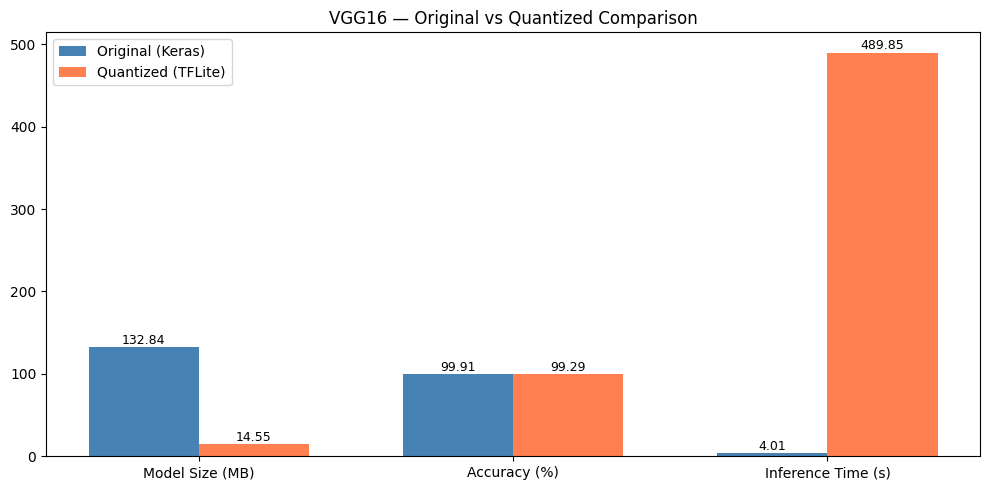

In [18]:
categories = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals  = [orig_size, orig_acc * 100, orig_time]
quant_vals = [quant_size, quant_acc, quant_time]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original (Keras)',   color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized (TFLite)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('VGG16 — Original vs Quantized Comparison')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 15. Confusion Matrix

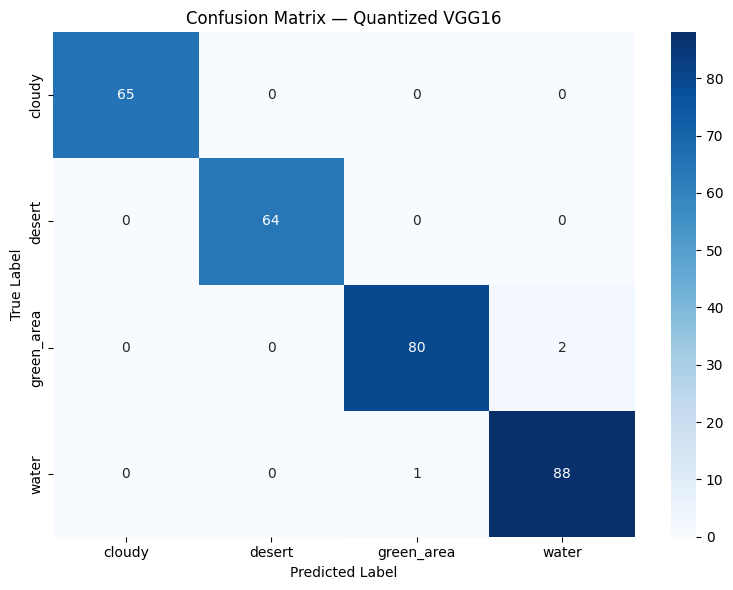

              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00        65
      desert       1.00      1.00      1.00        64
  green_area       0.99      0.98      0.98        82
       water       0.98      0.99      0.98        89

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [21]:
all_preds  = []
all_labels = []
count = 0

for images, labels in val_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        if count >= 300:
            break
        img_input = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        all_preds.append(np.argmax(output))
        all_labels.append(label)
        count += 1
    if count >= 300:
        break

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix — Quantized VGG16')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## 16. Download Models

In [22]:
from google.colab import files
files.download('satellite_vgg16.keras')
files.download('satellite_vgg16_quantized.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>